# Comparación entre KNN y árboles de decisión

Ejemplo sencillo para clase: clasificar pacientes ficticios en **COVID-19, Gripe o Resfriado**.

Vamos a preparar variables numéricas y una categórica, calcular distancias, entrenar ambos modelos, diferenciar **exactitud y precisión**, probar distintos valores de **k** y observar qué ocurre con datos desbalanceados.

Los datos y sus relaciones son simulados para enseñar; no representan un modelo médico. Ejecutar las celdas en orden. Se necesita scikit-learn ≥ 1.2.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, ConfusionMatrixDisplay)

clases = ['COVID-19', 'Gripe', 'Resfriado']


## 1. Crear los datos

Conservamos los cinco síntomas de la notebook original y agregamos **edad**, **días con síntomas** y **tipo de tos**.

| Variables | Tipo y valores |
|---|---|
| fiebre, tos, dolor_muscular, perdida_olfato, fatiga | Numéricas entre 0 y 1 |
| edad | Numérica: años |
| dias_sintomas | Numérica: días |
| tipo_tos | Categórica nominal: seca, productiva o sin_tos |
| enfermedad | Clase que queremos predecir |

Generamos 300 pacientes por clase. Los perfiles se superponen: no todos los pacientes de una enfermedad tienen los mismos síntomas. Edad se genera sin relación con la enfermedad: agregar una variable no garantiza mejorar el modelo.


In [ ]:
rng = np.random.default_rng(42)
partes = []

# Medias ficticias: fiebre, tos, dolor muscular, pérdida de olfato y fatiga.
perfiles = {
    'COVID-19': [0.62, 0.65, 0.48, 0.68, 0.62],
    'Gripe': [0.75, 0.55, 0.75, 0.25, 0.72],
    'Resfriado': [0.30, 0.50, 0.30, 0.20, 0.35]
}
probabilidades_tos = {
    'COVID-19': [0.70, 0.20, 0.10],
    'Gripe': [0.50, 0.40, 0.10],
    'Resfriado': [0.25, 0.45, 0.30]
}

for enfermedad in clases:
    sintomas = rng.normal(perfiles[enfermedad], 0.23, size=(3000, 5))
    pacientes = pd.DataFrame(np.clip(sintomas, 0, 1), columns=[
        'fiebre', 'tos', 'dolor_muscular', 'perdida_olfato', 'fatiga'])
    pacientes['edad'] = rng.integers(18, 81, size=3000)
    media_dias = {'COVID-19': 6, 'Gripe': 4, 'Resfriado': 3}[enfermedad]
    pacientes['dias_sintomas'] = np.clip(
        rng.normal(media_dias, 2, size=3000).round(), 1, 14).astype(int)
    pacientes['tipo_tos'] = rng.choice(
        ['seca', 'productiva', 'sin_tos'], size=3000,
        p=probabilidades_tos[enfermedad])
    pacientes['enfermedad'] = enfermedad
    partes.append(pacientes)

df = pd.concat(partes, ignore_index=True)
display(df.head())
display(df['enfermedad'].value_counts().to_frame('Pacientes'))


,fiebre,tos,dolor_muscular,perdida_olfato,fatiga,edad,dias_sintomas,tipo_tos,enfermedad
0,0.690085,0.410804,0.652604,0.896330,0.171262,72,8,seca,COVID-19
1,0.320499,0.679403,0.407264,0.676136,0.423800,64,3,seca,COVID-19
2,0.822262,0.828892,0.495187,0.939265,0.727527,35,6,seca,COVID-19
3,0.422363,0.734813,0.259457,0.882044,0.608517,38,7,sin_tos,COVID-19
4,0.577482,0.493386,0.761185,0.644458,0.521485,80,8,productiva,COVID-19


,Pacientes
enfermedad,
COVID-19,3000
Gripe,3000
Resfriado,3000


## 2. Separar entrenamiento y prueba

Usamos 70% para aprender y 30% para evaluar. Los dos modelos se prueban sobre los mismos pacientes. `stratify=y` conserva las proporciones de las clases; no balancea un dataset desbalanceado.

`X` contiene los predictores; `y` contiene la enfermedad. La enfermedad nunca se incluye entre las variables de entrada.


In [ ]:
X = df.drop(columns='enfermedad')
y = df['enfermedad']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)
#stratify=y es un parámetro usado en la función train_test_split de librerías para garantizar que los conjuntos de entrenamiento y de prueba conserven la misma proporción de clases o etiquetas que el conjunto de datos original

numericas = ['fiebre', 'tos', 'dolor_muscular', 'perdida_olfato',
             'fatiga', 'edad', 'dias_sintomas']
print('Pacientes para entrenar:', len(X_train))
print('Pacientes para evaluar:', len(X_test))


Pacientes para entrenar: 6300
Pacientes para evaluar: 2700


## 3. Convertir la variable categórica a números

No existe un orden entre seca, productiva y sin_tos. Por eso usamos **One-Hot Encoding**: una columna 0/1 por categoría. Asignarles 0, 1 y 2 inventaría un orden y distancias.

Tanto KNN como `DecisionTreeClassifier` necesitan aquí predictores numéricos. Las etiquetas de `y` pueden seguir siendo texto.

`fit` aprende las categorías de entrenamiento; `transform` las convierte. El doble corchete `[['tipo_tos']]` mantiene la entrada como una tabla de dos dimensiones. `handle_unknown='ignore'` evita errores si aparece una categoría nueva: su bloque se representa con ceros.


In [ ]:
codificador = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
codificador.fit(X_train[['tipo_tos']])
columnas_cat = codificador.get_feature_names_out(['tipo_tos'])

train_cat = pd.DataFrame(codificador.transform(X_train[['tipo_tos']]),
                         columns=columnas_cat, index=X_train.index)
test_cat = pd.DataFrame(codificador.transform(X_test[['tipo_tos']]),
                        columns=columnas_cat, index=X_test.index)
display(pd.concat([X_train[['tipo_tos']], train_cat], axis=1).head())

X_train_arbol = pd.concat([X_train[numericas], train_cat], axis=1)
X_test_arbol = pd.concat([X_test[numericas], test_cat], axis=1)


,tipo_tos,tipo_tos_productiva,tipo_tos_seca,tipo_tos_sin_tos
2063,productiva,1.0,0.0,0.0
2469,productiva,1.0,0.0,0.0
7061,sin_tos,0.0,0.0,1.0
2737,seca,0.0,1.0,0.0
1216,seca,0.0,1.0,0.0


## 4. Escalar para KNN

Una diferencia de 40 años podría dominar una diferencia de 0.4 en fiebre por sus unidades. Estandarizamos las numéricas: restamos su media y dividimos por su desviación estándar. Los indicadores de tipo de tos quedan en 0/1.

El escalador aprende **solo con entrenamiento**. En prueba usamos únicamente `transform`. El árbol no necesita este escalado porque hace cortes sobre una variable por vez.


In [ ]:
scaler = StandardScaler()
scaler.fit(X_train[numericas])
train_num = pd.DataFrame(scaler.transform(X_train[numericas]),
                         columns=numericas, index=X_train.index)
test_num = pd.DataFrame(scaler.transform(X_test[numericas]),
                        columns=numericas, index=X_test.index)
X_train_knn = pd.concat([train_num, train_cat], axis=1)
X_test_knn = pd.concat([test_num, test_cat], axis=1)


## 5. KNN: ¿cómo calcula quién está cerca?

KNN compara un paciente nuevo con los pacientes de entrenamiento. Para medir cercanía podemos usar la **distancia euclídea**. Cuanto menor es la distancia, más parecidos son los valores de sus variables.

Recuperamos la fórmula y el ejemplo de los dos pacientes de la notebook original:


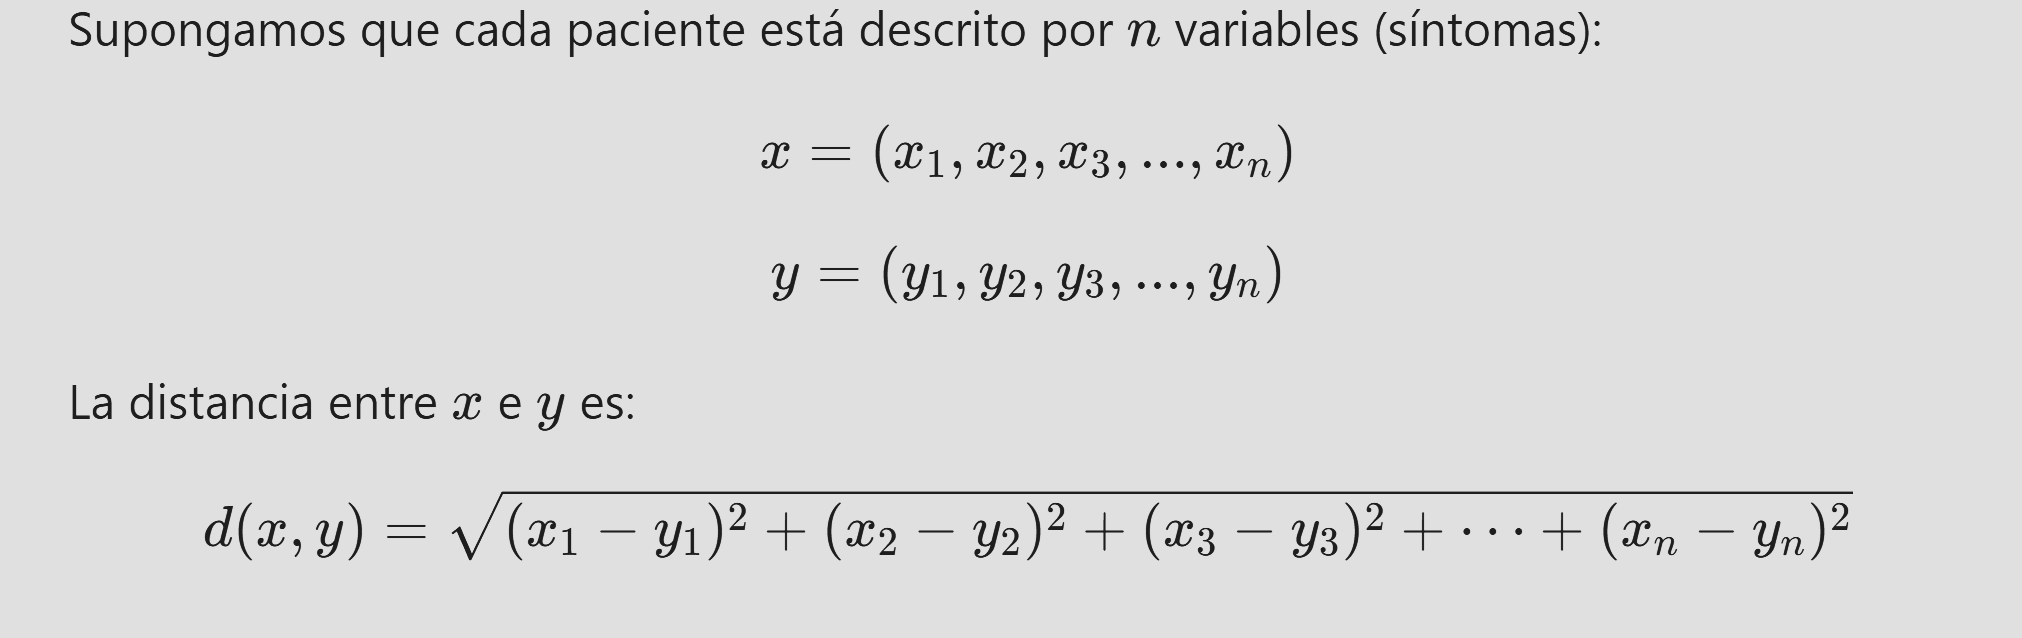

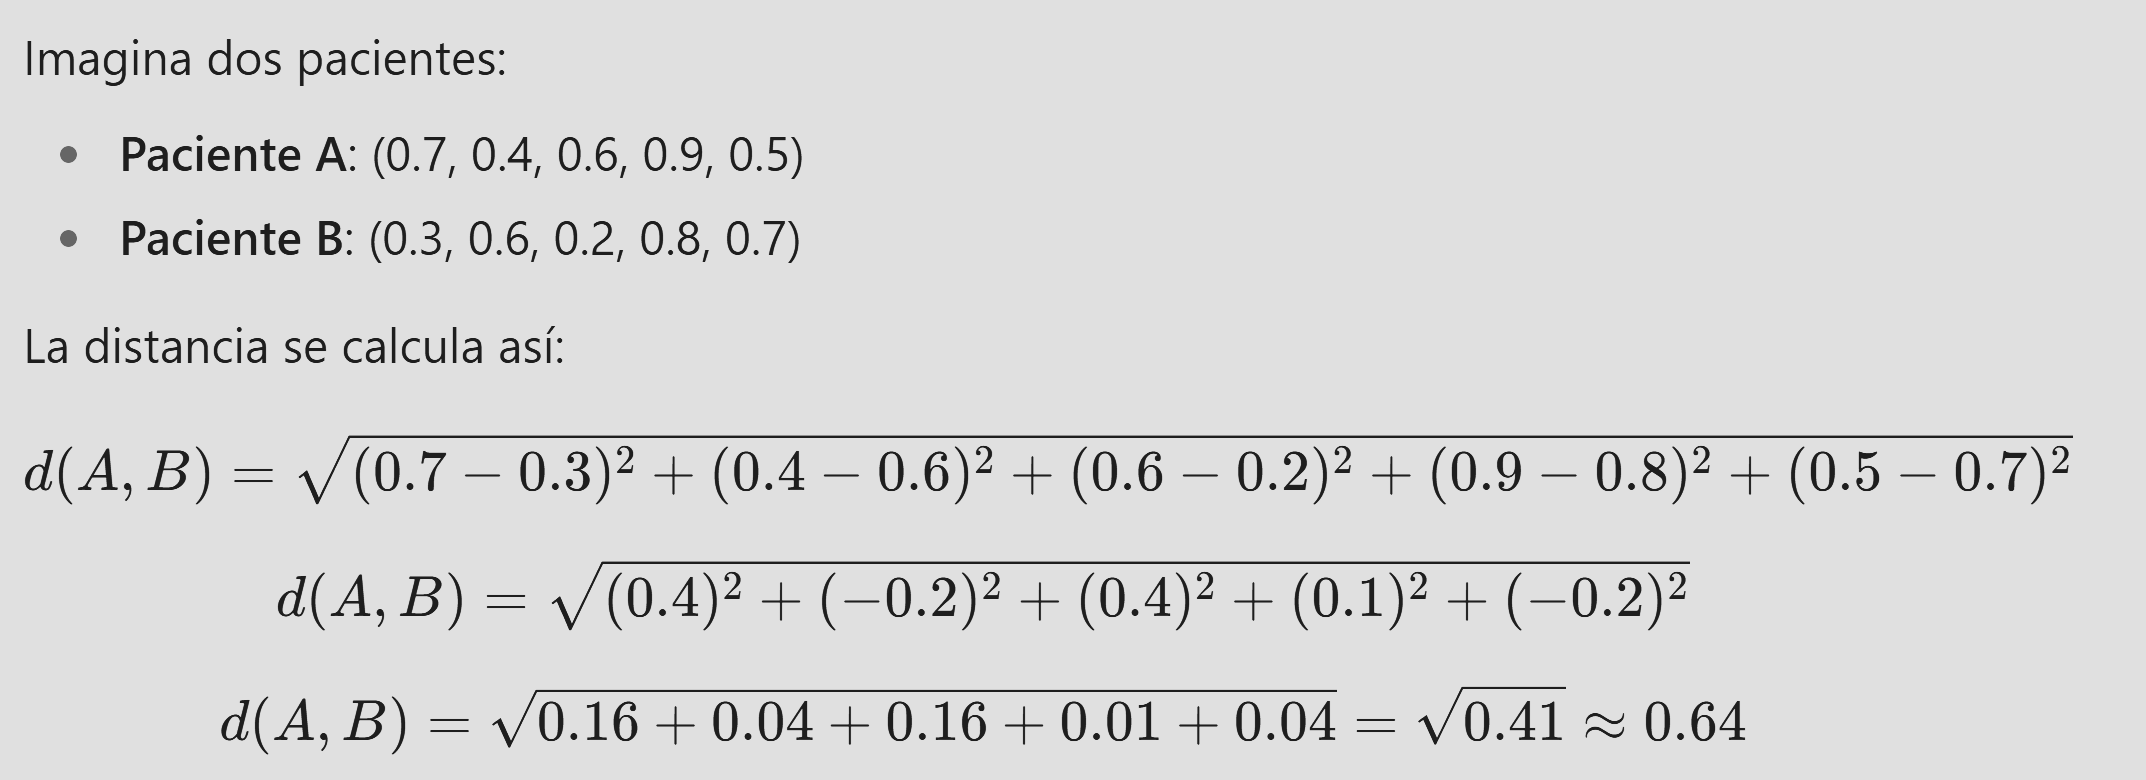


En la fórmula, $n$ es la cantidad de variables. Se resta cada par de valores, se eleva la diferencia al cuadrado, se suman los resultados y se obtiene la raíz cuadrada.

Para los pacientes del ejemplo:

$$d(A,B)=\sqrt{0.16+0.04+0.16+0.01+0.04}=\sqrt{0.41}\approx 0.6403$$

Este cálculo usa solo los **cinco síntomas originales**, para que sea fácil hacerlo a mano. Nuestro modelo completo calcula la distancia con **todas las columnas preparadas**: numéricas escaladas e indicadores de tipo de tos.


In [ ]:
A = np.array([0.7, 0.4, 0.6, 0.9, 0.5])
B = np.array([0.3, 0.6, 0.2, 0.8, 0.7])
diferencias = A - B
cuadrados = diferencias ** 2
distancia = np.sqrt(cuadrados.sum())
print('Diferencias:', diferencias)
print('Diferencias al cuadrado:', cuadrados)
print('Suma:', cuadrados.sum())
print('Distancia euclídea:', round(distancia, 4))


Diferencias: [ 0.4 -0.2  0.4  0.1 -0.2]
Diferencias al cuadrado: [0.16 0.04 0.16 0.01 0.04]
Suma: 0.4099999999999999
Distancia euclídea: 0.6403


### ¿Cómo decide la clase? Parámetros de KNN

- **`n_neighbors` (k):** cantidad de vecinos que consulta. Con k=5 y voto uniforme, si 3 tienen Gripe y 2 Resfriado, predice Gripe. Un k pequeño puede seguir el ruido; uno muy grande puede perder diferencias importantes.
- **`weights='uniform'`:** todos los vecinos tienen el mismo voto.
- **`weights='distance'`:** los más cercanos pesan más (para distancias mayores que cero, el peso es inversamente proporcional a la distancia). Puede ganar una clase con menos vecinos si están mucho más cerca. No garantiza mejores resultados.
- **`metric='euclidean'`:** usa la distancia que acabamos de calcular.

Comenzamos con k=5 y voto por distancia. Más adelante probaremos otros k con un `for`.


In [ ]:
knn = KNeighborsClassifier(n_neighbors=5, weights='distance', metric='euclidean')
knn.fit(X_train_knn, y_train)
y_pred_knn = knn.predict(X_test_knn)


## 6. Árbol de decisión: pureza y Gini

Un árbol hace preguntas sobre las variables y divide los pacientes en grupos. **Un grupo es puro cuando todos sus pacientes pertenecen a la misma clase.** Si mezcla varias clases, tiene impureza.

- 10 pacientes con Gripe: grupo completamente puro.
- 7 con Gripe y 3 con Resfriado: grupo mezclado, pero predomina Gripe.
- 5 con Gripe y 5 con Resfriado: mayor mezcla que el caso anterior.

**Gini se suele usar y es el criterio predeterminado de `DecisionTreeClassifier`. Mide impureza:** un valor menor significa mayor pureza.

$$Gini=1-(p_1^2+p_2^2+\cdots+p_c^2)$$

Para 7 de Gripe y 3 de Resfriado: $1-(0.7^2+0.3^2)=0.42$.
Para 10 de la misma clase: $1-1^2=0$. Con dos clases iguales, Gini=0.5; con tres clases iguales, Gini≈0.667. El máximo depende del número de clases.

El árbol busca cortes que reduzcan la impureza, considerando el tamaño de los grupos que forma.

### ¿Podemos elegir el grado de pureza como hiperparámetro?

No existe un parámetro que diga «quiero 90% de pureza» ni que fije directamente el Gini final. **Sí podemos controlar cuánto debe mejorar un corte**, mediante `min_impurity_decrease`.

| Hiperparámetro | Qué elegimos |
|---|---|
| `criterion='gini'` | Medir impureza con Gini |
| `min_impurity_decrease=0.0` | No exigir una reducción positiva mínima adicional |
| `min_impurity_decrease=0.01` | Aceptar un corte solo si reduce al menos 0.01 la impureza ponderada |
| `max_depth=4` | Permitir hasta cuatro niveles de divisiones |
| `min_samples_leaf=5` | Exigir al menos cinco pacientes en cada hoja |

**0.01 no significa 1% de pureza.** La reducción se pondera por la cantidad de pacientes de los nodos respecto del entrenamiento. Un valor mayor exige más mejora para dividir y suele producir menos ramas; no garantiza hojas más puras. Un árbol puede terminar con hojas mezcladas por estas restricciones.

Buscar hojas perfectamente puras puede llevar a memorizar los datos y **sobreajustar**. Por eso también limitamos profundidad y tamaño de hoja.


In [ ]:
arbol = DecisionTreeClassifier(criterion='gini', max_depth=4,
    min_samples_leaf=5, min_impurity_decrease=0.0, random_state=42)
arbol.fit(X_train_arbol, y_train)
y_pred_arbol = arbol.predict(X_test_arbol)

print('Gini de un grupo con 7 de Gripe y 3 de Resfriado:', round(1 - (0.7**2 + 0.3**2), 2))
print('Gini de un grupo completamente puro:', 1 - 1**2)


Gini de un grupo con 7 de Gripe y 3 de Resfriado: 0.42
Gini de un grupo completamente puro: 0


## 7. Exactitud y precisión: diferencia y cálculo

**Exactitud (accuracy):** de todos los pacientes, ¿qué proporción clasifiqué correctamente?

$$Exactitud=\frac{\text{cantidad de aciertos}}{\text{cantidad total de pacientes}}$$

**Precisión (precision) de COVID-19:** de los pacientes que el modelo predijo como COVID-19, ¿cuántos realmente tenían esa etiqueta?

$$Precisión_{COVID}=\frac{VP}{VP+FP}$$

- **VP (verdaderos positivos):** predijo COVID-19 y realmente era COVID-19.
- **FP (falsos positivos):** predijo COVID-19 pero era otra enfermedad.

La exactitud resume los aciertos de **las tres clases**. La precisión se calcula **para cada clase**: no son sinónimos.

### Ejemplo de 10 pacientes

Supongamos que la matriz de confusión es la siguiente (filas reales y columnas predichas):

| Real / Predicha | COVID-19 | Gripe | Resfriado |
|---|---:|---:|---:|
| COVID-19 | 2 | 1 | 0 |
| Gripe | 1 | 2 | 0 |
| Resfriado | 0 | 1 | 3 |

- **Exactitud:** los aciertos están en la diagonal: $(2+2+3)/10=7/10=70\%$.
- **Precisión de COVID-19:** predijo 3 COVID-19 y acertó 2: $2/3=66.7\%$.
- **Precisión de Gripe:** predijo 4 Gripe y acertó 2: $2/4=50\%$.
- **Precisión de Resfriado:** predijo 3 Resfriado y acertó 3: $3/3=100\%$.

Una precisión de 100% para Resfriado no significa que todo el modelo tenga 100% de exactitud.

Las otras métricas que ya aparecían en la notebook:

| Métrica por clase | Qué responde | Fórmula |
|---|---|---|
| Recall / sensibilidad | De los pacientes reales de esa clase, ¿cuántos detectó? | VP / (VP + FN) |
| F1 | ¿Cómo combina precisión y recall? | 2 × precisión × recall / (precisión + recall) |

FN son los casos reales de la clase que el modelo confundió con otra. Para COVID-19, el recall del ejemplo es 2/3; para Resfriado es 3/4. No agregaremos promedios entre clases.


In [ ]:
# Comprobar a mano el ejemplo de 10 pacientes.
matriz_ejemplo = np.array([[2, 1, 0], [1, 2, 0], [0, 1, 3]])
aciertos = 2 + 2 + 3
total = matriz_ejemplo.sum()
print(f'Exactitud: {aciertos}/{total} = {aciertos / total:.1%}')

for i, clase in enumerate(clases):
    VP = matriz_ejemplo[i, i]
    predichos_como_clase = matriz_ejemplo[:, i].sum()
    precision = VP / predichos_como_clase
    print(f'Precisión {clase}: {VP}/{predichos_como_clase} = {precision:.1%}')


Exactitud: 7/10 = 70.0%
Precisión COVID-19: 2/3 = 66.7%
Precisión Gripe: 2/4 = 50.0%
Precisión Resfriado: 3/3 = 100.0%


### Calcular las métricas de los modelos

Mostramos exactitud general y una tabla con precisión, recall y F1 **de cada enfermedad**, sin promedios. En estas funciones, `average=None` significa devolver un resultado por clase.

`zero_division=0` muestra cero si no se puede calcular una proporción, por ejemplo si el modelo nunca predice una clase. Ese caso merece atención.


In [ ]:
for nombre, pred in [('KNN', y_pred_knn), ('Árbol', y_pred_arbol)]:
    print('\nModelo:', nombre)
    print(f'Exactitud: {accuracy_score(y_test, pred):.1%}')
    tabla = pd.DataFrame({
        'Precisión': precision_score(y_test, pred, labels=clases, average=None, zero_division=0),
        'Recall': recall_score(y_test, pred, labels=clases, average=None, zero_division=0),
        'F1': f1_score(y_test, pred, labels=clases, average=None, zero_division=0)
    }, index=clases)
    display(tabla.round(3))



Modelo: KNN
Exactitud: 86.6%


,Precisión,Recall,F1
COVID-19,0.834,0.859,0.846
Gripe,0.848,0.832,0.840
Resfriado,0.916,0.906,0.911



Modelo: Árbol
Exactitud: 79.9%


,Precisión,Recall,F1
COVID-19,0.791,0.780,0.785
Gripe,0.818,0.749,0.782
Resfriado,0.791,0.869,0.828


### Volver a calcular exactitud y precisión contando casos reales

Para comprobar que entendemos las funciones, contamos aciertos, VP y FP de las predicciones de cada modelo. Elegimos COVID-19 como clase de interés; se puede cambiar por Gripe o Resfriado.


In [ ]:
clase_interes = 'COVID-19'
for nombre, pred in [('KNN', y_pred_knn), ('Árbol', y_pred_arbol)]:
    aciertos = (y_test == pred).sum()
    total = len(y_test)
    VP = ((y_test == clase_interes) & (pred == clase_interes)).sum()
    FP = ((y_test != clase_interes) & (pred == clase_interes)).sum()
    precision = VP / (VP + FP) if VP + FP > 0 else 0
    print('\n', nombre)
    print(f'Exactitud = {aciertos}/{total} = {aciertos / total:.1%}')
    print(f'Precisión {clase_interes} = {VP}/({VP}+{FP}) = {precision:.1%}')



 KNN
Exactitud = 2337/2700 = 86.6%
Precisión COVID-19 = 773/(773+154) = 83.4%

 Árbol
Exactitud = 2158/2700 = 79.9%
Precisión COVID-19 = 702/(702+186) = 79.1%


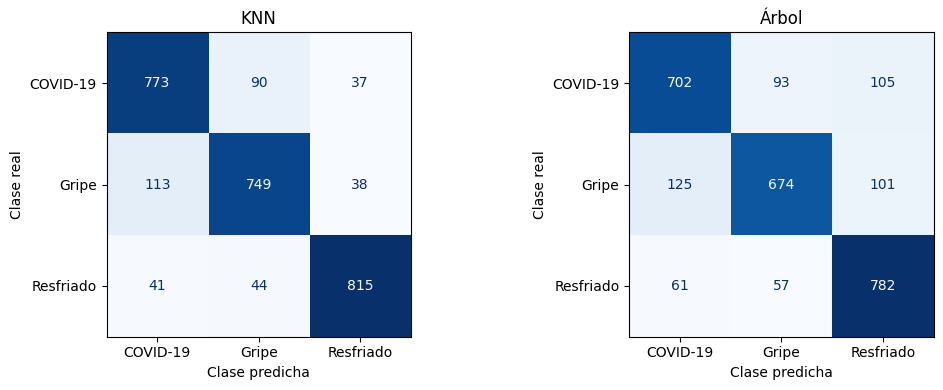

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, nombre, pred in zip(axes, ['KNN', 'Árbol'], [y_pred_knn, y_pred_arbol]):
    ConfusionMatrixDisplay.from_predictions(y_test, pred, labels=clases,
        ax=ax, colorbar=False, cmap='Blues', values_format='d')
    ax.set(title=nombre, xlabel='Clase predicha', ylabel='Clase real')
plt.tight_layout()
plt.show()


## 8. Probar distintos valores de k con un `for`

En cada vuelta creamos KNN con otro k, lo entrenamos y calculamos las métricas sobre los mismos pacientes. Mantenemos las variables, el escalado y `weights='distance'` para que solo cambie k.

Comparamos **exactitud general** y **precisión, recall y F1 de COVID-19**, sin promedios. Para estudiar otra enfermedad, cambiar `clase_interes`.

Este recorrido sirve para observar diferencias en clase. Como repetimos la evaluación sobre test, **no debemos elegir el mejor k de esta tabla y presentar ese mismo resultado como evaluación final**. Para elegir k en un trabajo real, usar validación y reservar test para el final.


,Exactitud general,Precisión COVID-19,Recall COVID-19,F1 COVID-19
k,,,,
1,0.819,0.782,0.802,0.792
3,0.859,0.829,0.848,0.838
5,0.866,0.834,0.859,0.846
7,0.876,0.841,0.879,0.859
11,0.880,0.850,0.877,0.863
21,0.889,0.859,0.883,0.871
31,0.891,0.863,0.887,0.875


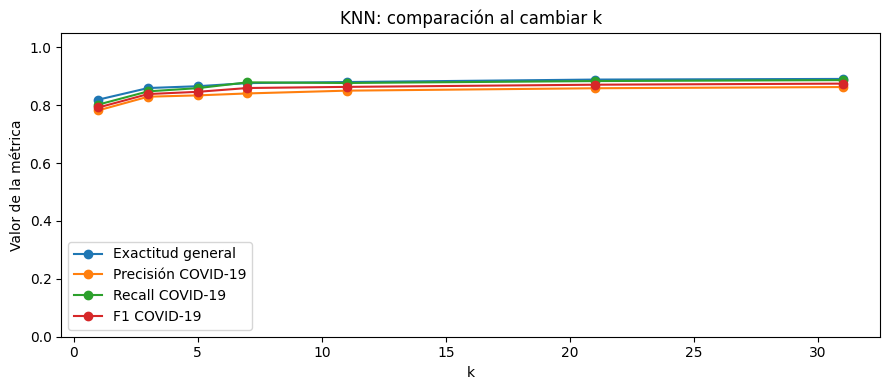

In [ ]:
resultados_k = []
clase_interes = 'COVID-19'

for k in [1, 3, 5, 7, 11, 21, 31]:
    modelo = KNeighborsClassifier(n_neighbors=k, weights='distance', metric='euclidean')
    modelo.fit(X_train_knn, y_train)
    pred = modelo.predict(X_test_knn)

    # True = pertenece a la clase de interés; False = otra enfermedad.
    reales_clase = y_test == clase_interes
    predichos_clase = pred == clase_interes

    resultados_k.append({
        'k': k,
        'Exactitud general': accuracy_score(y_test, pred),
        'Precisión ' + clase_interes: precision_score(reales_clase, predichos_clase, zero_division=0),
        'Recall ' + clase_interes: recall_score(reales_clase, predichos_clase, zero_division=0),
        'F1 ' + clase_interes: f1_score(reales_clase, predichos_clase, zero_division=0)
    })

tabla_k = pd.DataFrame(resultados_k).set_index('k')
display(tabla_k.round(3))
tabla_k.plot(marker='o', figsize=(9, 4), ylim=(0, 1.05))
plt.title('KNN: comparación al cambiar k')
plt.ylabel('Valor de la métrica')
plt.tight_layout()
plt.show()


**Para interpretar:** ¿el k con mayor exactitud también tiene mayor precisión? ¿Cuál detecta más COVID-19? ¿Subir k siempre mejora? Los resultados dependen del dataset y de la métrica que necesitamos priorizar.

## 9. Visualizar el árbol y las fronteras

En el árbol, `gini` indica impureza, `samples` es la cantidad de pacientes de entrenamiento del nodo y `value` muestra la distribución de clases (conteos o proporciones según la versión). `class` es la clase predicha. El orden de `value` es el de `arbol.classes_`.

Izquierda: se cumple la condición `≤`. Derecha: no se cumple. Observar hojas puras y hojas mezcladas.


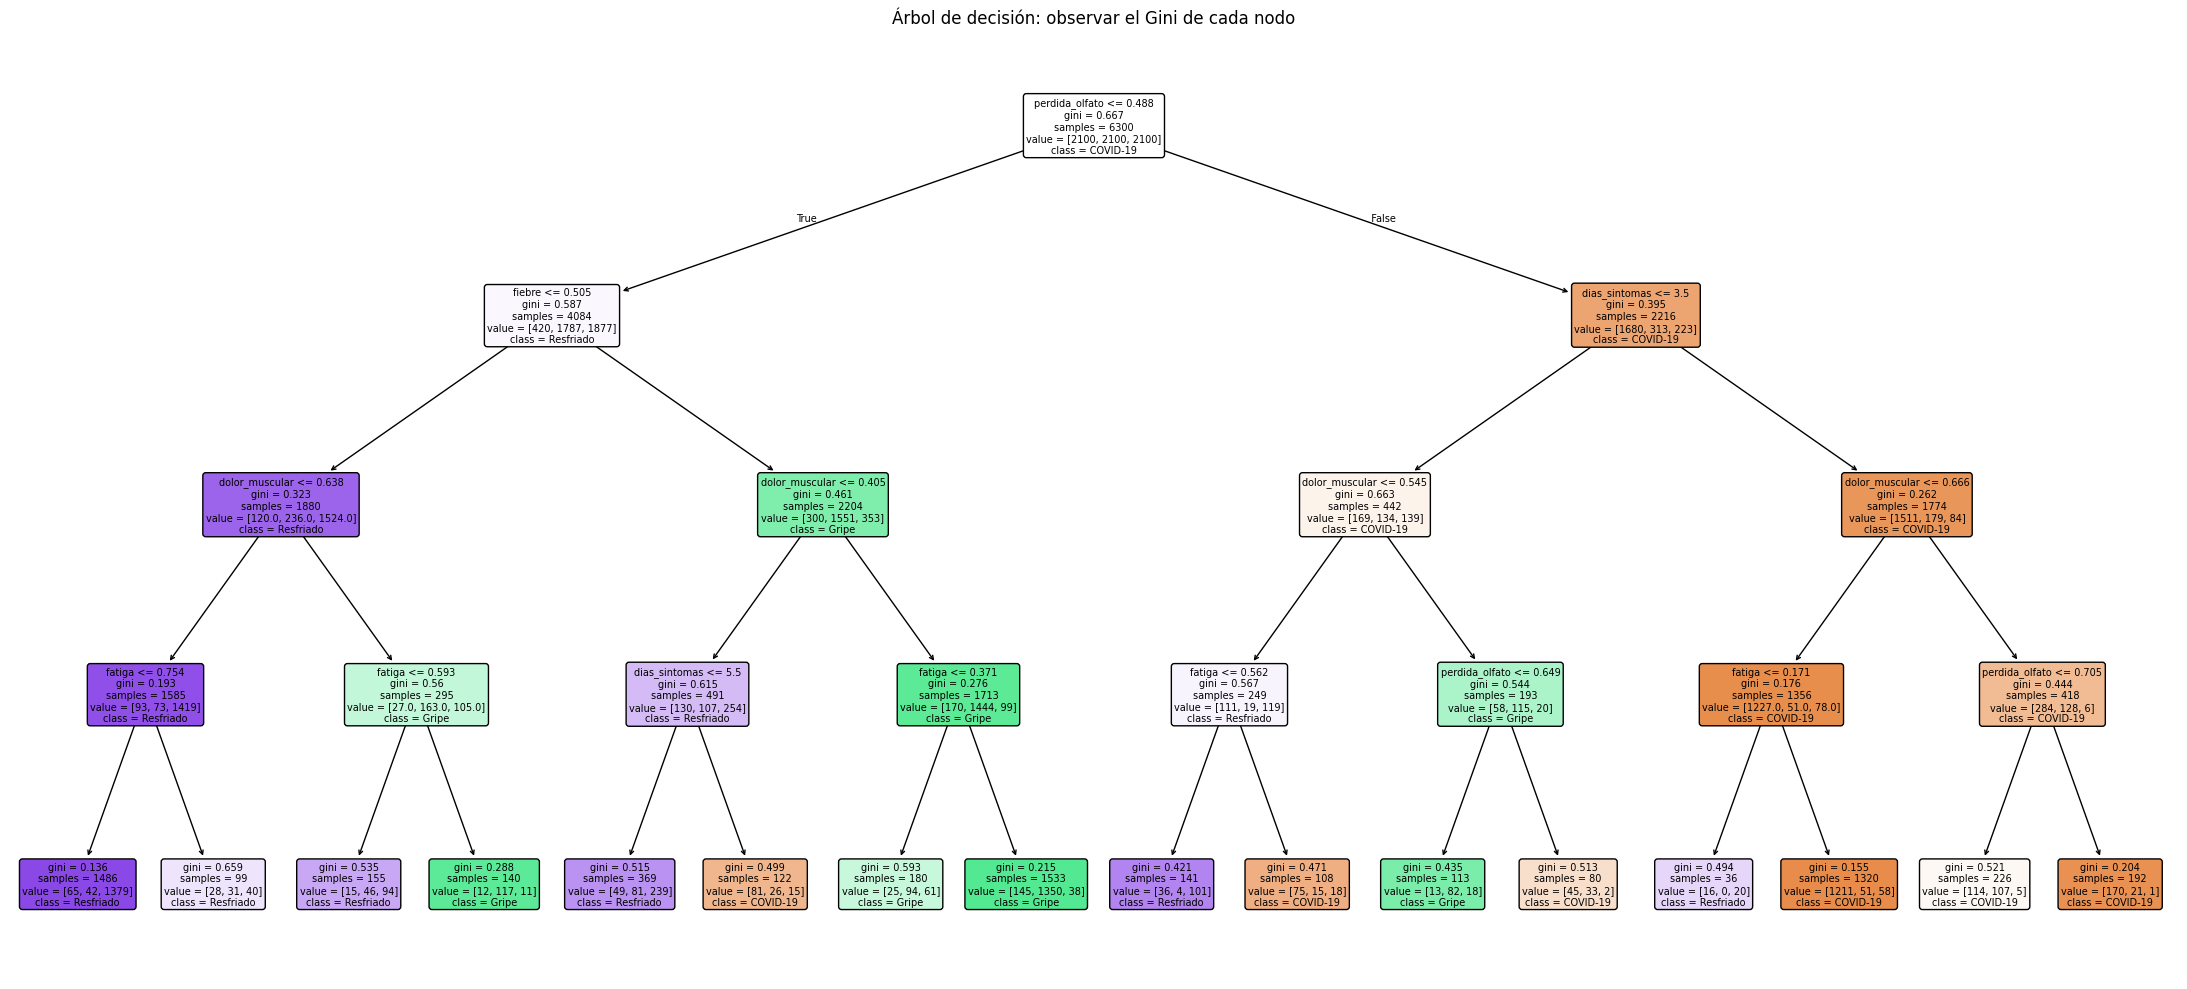

In [ ]:
plt.figure(figsize=(22, 10))
plot_tree(arbol, feature_names=list(X_train_arbol.columns),
          class_names=list(arbol.classes_), filled=True, rounded=True, fontsize=7)
plt.title('Árbol de decisión: observar el Gini de cada nodo')
plt.tight_layout()
plt.show()


### Fronteras con solo dos variables

Para dibujar, ajustamos dos modelos aparte con **fiebre y pérdida de olfato**. El fondo indica la predicción; los puntos son pacientes de prueba. Estas no son las fronteras del modelo con todas las variables.


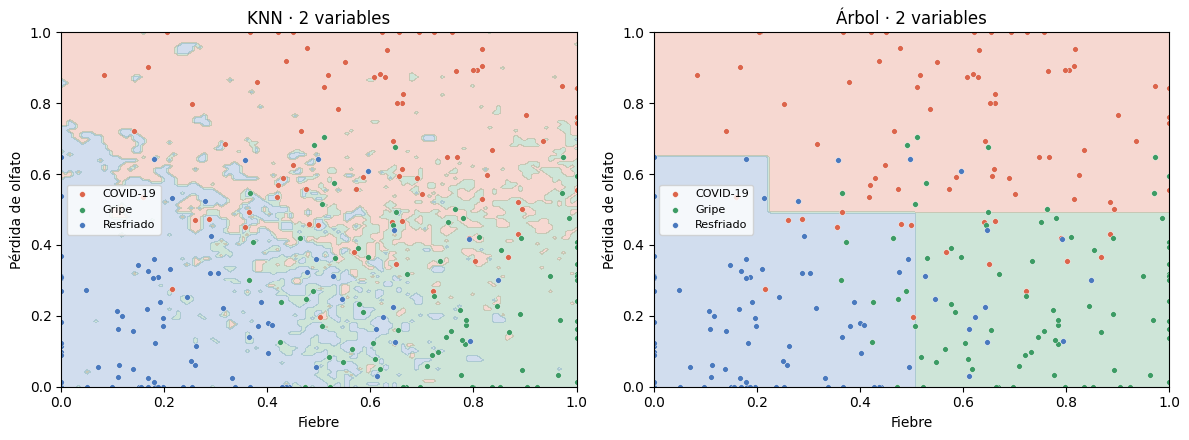

In [ ]:
from matplotlib.colors import ListedColormap
variables_2d = ['fiebre', 'perdida_olfato']
escalador_2d = StandardScaler()
escalador_2d.fit(X_train[variables_2d])
knn_2d = KNeighborsClassifier(n_neighbors=5, weights='distance')
knn_2d.fit(escalador_2d.transform(X_train[variables_2d]), y_train)
arbol_2d = DecisionTreeClassifier(max_depth=4, min_samples_leaf=5, random_state=42)
arbol_2d.fit(X_train[variables_2d], y_train)

xx, yy = np.meshgrid(np.linspace(0, 1, 120), np.linspace(0, 1, 120))
malla = pd.DataFrame({'fiebre': xx.flatten(), 'perdida_olfato': yy.flatten()})
predicciones_2d = [knn_2d.predict(escalador_2d.transform(malla)), arbol_2d.predict(malla)]
colores = ['#dc654b', '#3c9b64', '#4979be']
mapa_clases = {clase: i for i, clase in enumerate(clases)}
mostrar = X_test.sample(n=250, random_state=42)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, nombre, pred in zip(axes, ['KNN · 2 variables', 'Árbol · 2 variables'], predicciones_2d):
    z = pd.Series(pred).map(mapa_clases).to_numpy().reshape(xx.shape)
    ax.contourf(xx, yy, z, levels=[-0.5, 0.5, 1.5, 2.5], cmap=ListedColormap(colores), alpha=0.25)
    for clase, color in zip(clases, colores):
        puntos = mostrar[y_test.loc[mostrar.index] == clase]
        ax.scatter(puntos['fiebre'], puntos['perdida_olfato'], c=color,
                   label=clase, s=17, edgecolors='white', linewidths=0.3)
    ax.set(title=nombre, xlabel='Fiebre', ylabel='Pérdida de olfato')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 10. Otro dataset con las mismas variables, pero desbalanceado

Armamos un dataset con **30 COVID-19, 30 Gripe y 300 Resfriado**. Resfriado representa el 83.3%. No cambiamos las etiquetas ni las columnas: seleccionamos menos pacientes de las clases minoritarias.

Lo dividimos nuevamente en entrenamiento y prueba. Cada modelo se entrena y evalúa con las mismas filas del segundo dataset.

**Al comparar con el primer experimento también cambian el tamaño y los pacientes de la muestra.** Esta es una demostración sencilla de un escenario desbalanceado, no una medición que aísle únicamente el efecto del desbalanceo.


In [ ]:
df_desbalanceado = pd.concat([
    df[df['enfermedad'] == 'COVID-19'].sample(n=100, random_state=42),
    df[df['enfermedad'] == 'Gripe'].sample(n=50, random_state=42),
    df[df['enfermedad'] == 'Resfriado']
])
display(df_desbalanceado['enfermedad'].value_counts().to_frame('Pacientes'))

X_des = df_desbalanceado.drop(columns='enfermedad')
y_des = df_desbalanceado['enfermedad']
X_train_des, X_test_des, y_train_des, y_test_des = train_test_split(
    X_des, y_des, test_size=0.30, random_state=42)


,Pacientes
enfermedad,
Resfriado,3000
COVID-19,100
Gripe,50


Repetimos la misma preparación: aprender categorías y escala solo del nuevo entrenamiento, y aplicarlas a su prueba.


In [ ]:
codificador_des = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
codificador_des.fit(X_train_des[['tipo_tos']])
nombres_des = codificador_des.get_feature_names_out(['tipo_tos'])
train_cat_des = pd.DataFrame(codificador_des.transform(X_train_des[['tipo_tos']]),
                            columns=nombres_des, index=X_train_des.index)
test_cat_des = pd.DataFrame(codificador_des.transform(X_test_des[['tipo_tos']]),
                           columns=nombres_des, index=X_test_des.index)
X_train_arbol_des = pd.concat([X_train_des[numericas], train_cat_des], axis=1)
X_test_arbol_des = pd.concat([X_test_des[numericas], test_cat_des], axis=1)

scaler_des = StandardScaler()
scaler_des.fit(X_train_des[numericas])
train_num_des = pd.DataFrame(scaler_des.transform(X_train_des[numericas]),
                            columns=numericas, index=X_train_des.index)
test_num_des = pd.DataFrame(scaler_des.transform(X_test_des[numericas]),
                           columns=numericas, index=X_test_des.index)
X_train_knn_des = pd.concat([train_num_des, train_cat_des], axis=1)
X_test_knn_des = pd.concat([test_num_des, test_cat_des], axis=1)


In [ ]:
# Mismos parámetros que los modelos del primer dataset.
knn_des = KNeighborsClassifier(n_neighbors=21, weights='distance', metric='euclidean')
knn_des.fit(X_train_knn_des, y_train_des)
pred_knn_des = knn_des.predict(X_test_knn_des)

arbol_des = DecisionTreeClassifier(criterion='gini', max_depth=4,
    min_samples_leaf=5, min_impurity_decrease=0.0, random_state=42)
arbol_des.fit(X_train_arbol_des, y_train_des)
pred_arbol_des = arbol_des.predict(X_test_arbol_des)

for nombre, pred in [('KNN', pred_knn_des), ('Árbol', pred_arbol_des)]:
    print('\nDataset desbalanceado —', nombre)
    print(f'Exactitud: {accuracy_score(y_test_des, pred):.1%}')
    tabla = pd.DataFrame({
        'Casos reales en test': y_test_des.value_counts().reindex(clases),
        'Precisión': precision_score(y_test_des, pred, labels=clases, average=None, zero_division=0),
        'Recall': recall_score(y_test_des, pred, labels=clases, average=None, zero_division=0),
        'F1': f1_score(y_test_des, pred, labels=clases, average=None, zero_division=0)
    }, index=clases)
    display(tabla.round(3))



Dataset desbalanceado — KNN
Exactitud: 97.0%


,Casos reales en test,Precisión,Recall,F1
COVID-19,30,0.850,0.567,0.680
Gripe,15,0.500,0.067,0.118
Resfriado,900,0.974,0.999,0.986



Dataset desbalanceado — Árbol
Exactitud: 96.2%


,Casos reales en test,Precisión,Recall,F1
COVID-19,30,0.571,0.400,0.471
Gripe,15,0.667,0.533,0.593
Resfriado,900,0.975,0.988,0.981


### Comparar ambos escenarios

La exactitud se calcula sobre todas las enfermedades; la precisión y el recall de esta tabla se refieren a **COVID-19**. Para revisar Gripe y Resfriado, usar las tablas anteriores.


In [ ]:
comparacion = []
for escenario, nombre, reales, pred in [
    ('Balanceado', 'KNN', y_test, y_pred_knn),
    ('Balanceado', 'Árbol', y_test, y_pred_arbol),
    ('Desbalanceado', 'KNN', y_test_des, pred_knn_des),
    ('Desbalanceado', 'Árbol', y_test_des, pred_arbol_des)
]:
    comparacion.append({
        'Dataset': escenario, 'Modelo': nombre,
        'Exactitud': accuracy_score(reales, pred),
        'Precisión COVID-19': precision_score(reales == 'COVID-19', pred == 'COVID-19', zero_division=0),
        'Recall COVID-19': recall_score(reales == 'COVID-19', pred == 'COVID-19', zero_division=0)
    })
display(pd.DataFrame(comparacion).round(3))

# Una regla que ignora los síntomas y siempre responde Resfriado.
pred_siempre_resfriado = np.repeat('Resfriado', len(y_test_des))
print('Si siempre respondemos Resfriado:')
print(f'Exactitud: {accuracy_score(y_test_des, pred_siempre_resfriado):.1%}')
print('No detectamos ningún COVID-19 ni ninguna Gripe.')


,Dataset,Modelo,Exactitud,Precisión COVID-19,Recall COVID-19
0,Balanceado,KNN,0.866,0.834,0.859
1,Balanceado,Árbol,0.799,0.791,0.780
2,Desbalanceado,KNN,0.972,0.895,0.567
3,Desbalanceado,Árbol,0.962,0.571,0.400


Si siempre respondemos Resfriado:
Exactitud: 95.2%
No detectamos ningún COVID-19 ni ninguna Gripe.


**¿Qué observamos?** Una regla que siempre responde Resfriado obtiene 83.3% de exactitud aunque omita por completo las otras enfermedades. Por eso miramos también precisión y recall de cada clase.

KNN puede encontrar muchos vecinos de la mayoría. El árbol puede favorecer cortes que beneficien a esa mayoría. Los efectos no tienen que ser iguales en ambos modelos.

En esta prueba hay solo 9 pacientes de cada enfermedad minoritaria: un acierto más o menos modifica mucho su recall. No debemos generalizar a partir de una sola ejecución.

**Preguntas para conversar:**

1. ¿Qué significa que un modelo tenga alta exactitud y bajo recall de COVID-19?
2. ¿Qué diferencia hay entre precisión de COVID-19 y exactitud general?
3. ¿Por qué usar edad sin escalar puede afectar a KNN?
4. ¿Un nodo con Gini=0 garantiza que el árbol funcionará bien con pacientes nuevos?
5. ¿El mismo k obtiene las mejores métricas en todos los casos?

**Ideas esperadas:** la mayoría puede ocultar errores en minorías; precisión mira las predicciones de una clase y exactitud todos los aciertos; las unidades afectan distancias; pureza en entrenamiento no garantiza generalización; elegir k depende de los datos y del objetivo.

Documentación: [KNN](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html), [árboles de decisión](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html) y [métricas](https://scikit-learn.org/stable/modules/model_evaluation.html).
